# Method1： Lomb–Scargle periodogram

一种适用于不均匀采样的功率谱分析方法，本质是：在每一个候选频率上，用最小二乘法拟合一个正弦波，看看它能解释多少方差。因此LSP方法也仅能检测正弦波信号。

## 🧮 1.1 数学定义（核心公式）

设光变数据为：
$$
{t_i, y_i, \sigma_i}, \quad i = 1,\dots,N
$$

我们要检测不同频率 $\omega = 2\pi f$ 下，是否存在周期性。

### (1) 拟合模型

在频率 $\omega$ 上拟合：
$$
y(t) = A \cos(\omega t) + B \sin(\omega t)
$$

通过最小二乘求出 $A, B$（即在该频率下的最佳拟合正弦波）。

### (2) 功率定义[（Scargle 1982）](https://ui.adsabs.harvard.edu/abs/1982ApJ...263..835S/abstract)

$$
P(\omega) = \frac{1}{2\sigma_y^2}
\left[
\frac{\left[\sum_i (y_i - \bar{y}) \cos \omega (t_i - \tau)\right]^2}
{\sum_i \cos^2 \omega (t_i - \tau)}
+
\frac{\left[\sum_i (y_i - \bar{y}) \sin \omega (t_i - \tau)\right]^2}
{\sum_i \sin^2 \omega (t_i - \tau)}
\right]
$$

其中：

* $\bar{y}$：数据均值；
* $\sigma_y^2$：方差；
* $\tau$：一个“时间偏移”，定义为：
  $$
  \tan(2\omega\tau) = \frac{\sum_i \sin 2\omega t_i}{\sum_i \cos 2\omega t_i}
  $$
  用来让正弦和余弦正交，提高稳健性。

这个 $P(\omega)$ 表示：

> 在频率 $\omega$ 上，一个正弦模型能解释数据方差的比例。

功率越大 → 周期信号越强。

## 🧠 1.2 直观理解

可以把 LSP 看成是在一系列频率上计算“相关系数”：

* 如果光变确实有周期 $P = 2\pi/\omega_0$，
* 那么在该频率附近的 $P(\omega)$ 会出现一个明显峰值。

即：

> **功率谱峰值 ↔ 周期信号存在的证据。**


## ⚙️ 1.3 实际计算流程

1. **选择频率范围**
   通常从 $f_{min} = 1/T_{obs}$ 到 $f_{max} = 1/(2\Delta t_{min})$，
   其中 $T_{obs}$ 是观测时间跨度，$\Delta t_{min}$ 是最小采样间隔。

2. **计算功率谱 P(f)**
   使用上述公式或快速算法（`astropy.timeseries.LombScargle` 支持）。

3. **寻找峰值频率**
   找出最大功率对应的周期 $P = 1/f_{peak}$。

4. **显著性检验 (False Alarm Probability, FAP)**

   4.1 在**白噪声**假设下，功率分布近似指数分布；
   * 单频FAP:
     $$
     p = 1 - [1 - e^{-z}]^M
     $$
     其中 $z = P_{max}$，$M$ 为独立频率数；
     
   4.2 在**红噪声**假设下：
   * 在**红噪声**假设下：拟合红噪声期望背景功率谱与目标峰对比。（REDFIT，AR1模型）
   * 在**红噪声**假设下：[Monte Carlo 模拟法](https://ui.adsabs.harvard.edu/abs/2013MNRAS.433..907E/abstract) 
   1. 拟合真实光变的功率谱分布 (PSD) 和 概率分布函数 (PDF)；
   2. 随机生成大量（1e4–1e5条）模拟光变，保持PSD和PDF一致；
   3. 对每条模拟光变计算LSP，得到“纯噪声情况下最大功率”的分布；
   4. 实测峰值的分位数 = 1 − FAP。
   → 如果实测峰高于 99.9% 的模拟峰值，就说“显著性 99.9%”（或FAP=0.001）。

>白噪声：White noise 均值为零，功率谱密度是常数。

>红噪声：Red noise 或 Brownian noise 或 1/f noise 指的是一种 低频功率更强、高频功率更弱 的随机信号。
>其功率谱密度（PSD）随频率f的变化遵循幂律：
>$$
>P(f) \propto \frac{1}{f^{\alpha}}
>$$
>物理来源：
>- AGN， XRB， 磁星等系统中，辐射功率来自一系列物理过程的乘性波动
>- 不同时间尺度的扰动叠加起来
>- 长时间尺度的扰动影响短时间变化，导致慢变化（低频）的振幅更大


---

## 💡 LSP 的优势 和 限制
### *Advantage*
- 适合不均匀采用
- 物理可解释性强
- 可以拓展：加入多谐波，漂移项，贝叶斯推广
### *Disadvantage*
- 红噪声 (1/f noise)容易产生假峰
- 有限时间基线，低频周期不可靠
- 多周期/准周期信号，峰可能宽、分裂


## 2.1 实例分析1：真实信号：主周期 + 次周期 + 漂移 + 红噪声

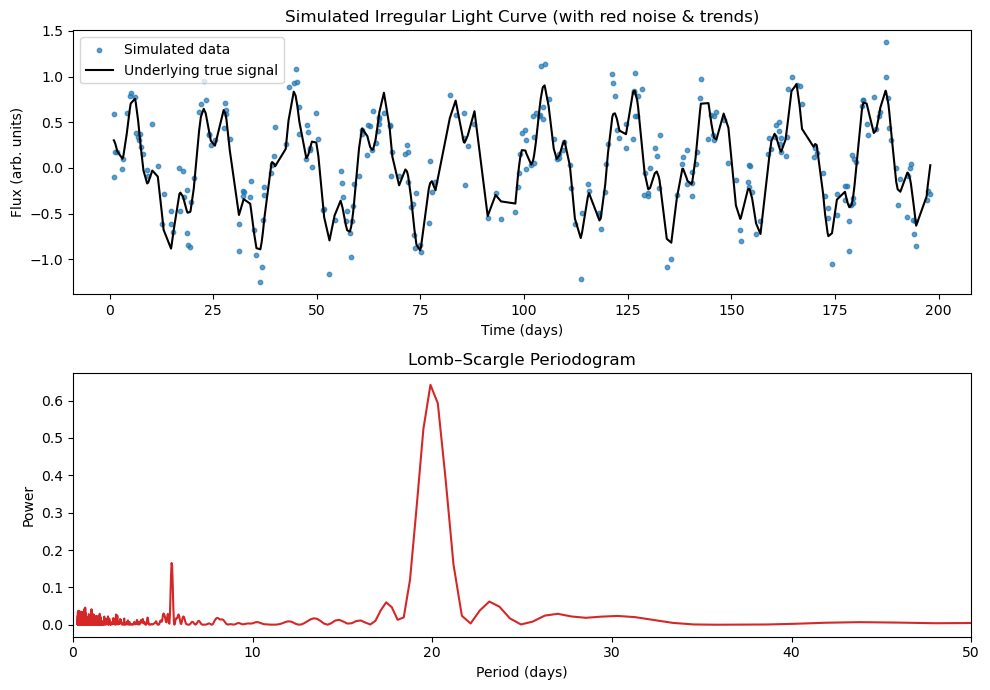

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle

# 1. 构造一个更复杂的模拟光变信号（类似真实天文数据）

# 时间：不均匀采样（类似卫星/地面观测）
np.random.seed(42)
t = np.sort(200 * np.random.rand(300))  # 0-200天

# 真实信号：主周期 + 次周期 + 漂移 + 红噪声
main_period = 20.0
sub_period = 5.5
trend = 0.001 * (t - np.mean(t))
signal = (
    0.6 * np.sin(2 * np.pi * t / main_period)
    + 0.3 * np.sin(2 * np.pi * t / sub_period + 1.2)
    + trend
)

# 噪声：混合高斯+红噪声（1/f^α）
alpha = 1.0
freqs = np.fft.rfftfreq(len(t), d=(np.median(np.diff(t))))
power = 1 / (freqs + 1e-3) ** alpha
phase = np.exp(2j * np.pi * np.random.rand(len(freqs)))
red_noise = np.fft.irfft(np.sqrt(power) * phase)
red_noise = np.interp(np.linspace(0, len(red_noise), len(t)), np.arange(len(red_noise)), red_noise)
noise = 0.3 * red_noise + 0.2 * np.random.randn(len(t))

y = signal + noise

# 2. 计算 Lomb-Scargle 功率谱
frequency, power = LombScargle(t, y).autopower(nyquist_factor=5)

# 3. 绘图
fig, ax = plt.subplots(2, 1, figsize=(10, 7))

# 光变图
ax[0].scatter(t, y, s=10, color='tab:blue', alpha=0.7, label='Simulated data')
ax[0].plot(t, signal, color='black', lw=1.5, label='Underlying true signal')
ax[0].set_xlabel("Time (days)")
ax[0].set_ylabel("Flux (arb. units)")
ax[0].set_title("Simulated Irregular Light Curve (with red noise & trends)")
ax[0].legend()

# 功率谱
ax[1].plot(1/frequency, power, color='tab:red')
ax[1].set_xlim(0, 50)
ax[1].set_xlabel("Period (days)")
ax[1].set_ylabel("Power")
ax[1].set_title("Lomb–Scargle Periodogram")

plt.tight_layout()
plt.show()

# 功率谱应该在5.5和20出线峰值


## 2.2 实例分析2：Fermi Mkn421 lightcurve


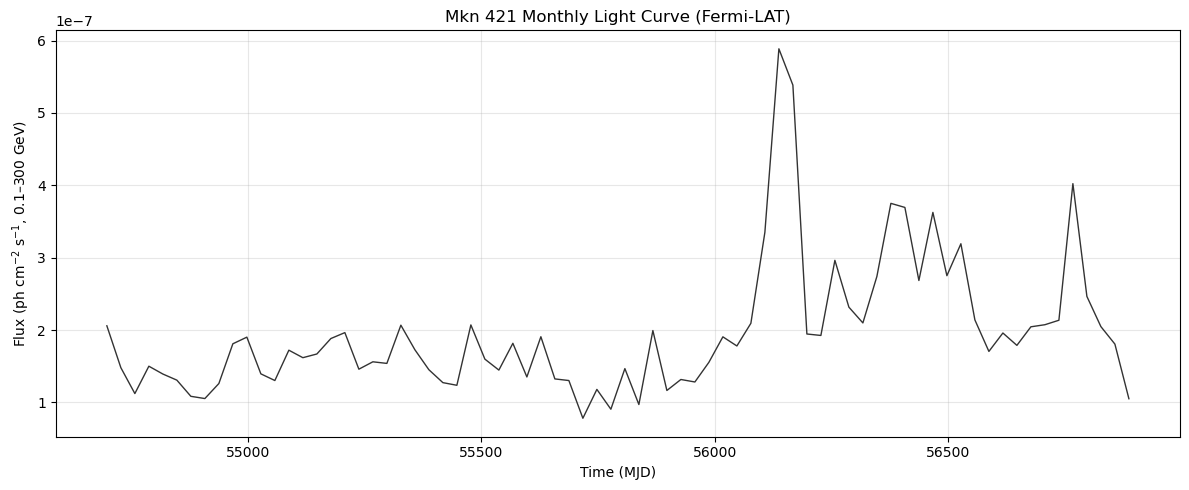

In [2]:
# 重加载light curve
from astropy.io import fits
import numpy as np

hdul = fits.open('/home/server/projects/PQO/mkn421/mkn421/4fgl_j1104.4+3812_lightcurve.fits')
lc = hdul[1].data

import numpy as np
import matplotlib.pyplot as plt

# 计算时间中心（MET）
t_met = 0.5 * (lc['tmin'] + lc['tmax'])

# 转换成 MJD bin=30d
t_mjd = t_met / 86400.0 + 51910.0
flux = lc['flux']
flux_err = lc['flux_err']
# 设置图像大小（长宽）
plt.figure(figsize=(12, 5))  # <-- 比较宽

# 绘制误差棒图
# plt.errorbar(t_center_mjd, lc['flux'], yerr=lc['flux_err'], fmt='o', markersize=3)
plt.plot(t_mjd, flux, color='0.2', linewidth=1)

plt.xlabel('Time (MJD)')
plt.ylabel('Flux (ph cm$^{-2}$ s$^{-1}$, 0.1–300 GeV)')
plt.title('Mkn 421 Monthly Light Curve (Fermi-LAT)')

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


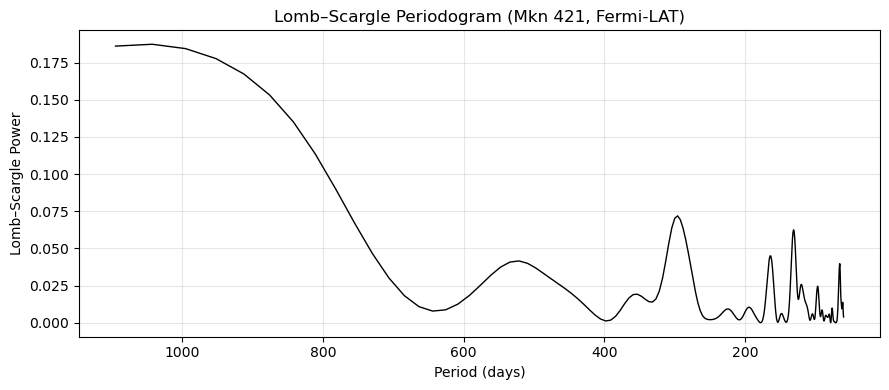

In [14]:
# 去除无效点
mask = (
    np.isfinite(flux) &
    np.isfinite(flux_err) &
    (flux > 0) &
    (flux_err > 0)
)

t = t_mjd[mask]
y = flux[mask]
yerr = flux_err[mask]
# 均值化
y_mean = np.mean(y)
y_detrend = y - y_mean

from astropy.timeseries import LombScargle

baseline = t.max() - t.min()

min_period = 60.0        # days（保守）
max_period = baseline / 2

min_freq = 1 / max_period
max_freq = 1 / min_period


ls = LombScargle(t, y_detrend, yerr)

frequency, power = ls.autopower(
    minimum_frequency=min_freq,
    maximum_frequency=max_freq,
    samples_per_peak=10
)

period = 1 / frequency


import matplotlib.pyplot as plt

plt.figure(figsize=(9,4))
plt.plot(period, power, color='k', lw=1)
plt.gca().invert_xaxis()  # 天文习惯：短周期在右

plt.xlabel('Period (days)')
plt.ylabel('Lomb–Scargle Power')
plt.title('Lomb–Scargle Periodogram (Mkn 421, Fermi-LAT)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

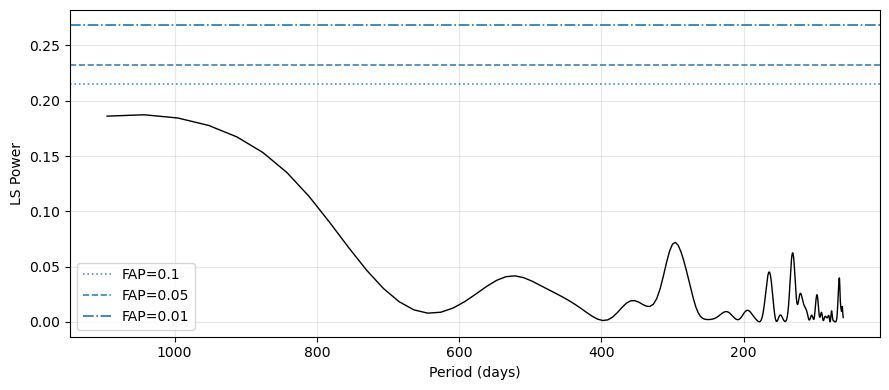

In [12]:
plt.figure(figsize=(9,4))
plt.plot(period, power, 'k', lw=1)
plt.gca().invert_xaxis()

styles = {
    0.1:  dict(ls=':',  lw=1.2, alpha=0.8),
    0.05: dict(ls='--', lw=1.2, alpha=0.9),
    0.01: dict(ls='-.', lw=1.2, alpha=1.0),
}

for fap, style in styles.items():
    plt.axhline(ls.false_alarm_level(fap),
                label=f'FAP={fap}',
                **style)

plt.xlabel('Period (days)')
plt.ylabel('LS Power')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


> 能看出300day左右有一个周期信号但是，显著性不高

>  在长周期的功率很高，说明有blazar的红噪声，周期不可信，这也是LSP方法的弊端，在红噪声情况下检验显著性要进行MC模拟

# Method2 :连续小波变换

> **CWT 是一种把时间序列同时展开到“时间–频率空间”的分析方法。**
> 相当于把信号在不同时间点、不同频率/周期下的强度都计算出来。



### 1.1 CWT 的数学定义

给定一个时间序列：

$$
x(t)
$$

CWT 的定义是：

$$
W(a, b)=\frac{1}{\sqrt{|a|}} \int_{-\infty}^\infty x(t) \psi^{*}\left(\frac{t-b}{a}\right)dt
$$

参数解释：

| 符号       | 含义                       |
| -------- | ------------------------ |
| $a$      | **尺度（scale）**：对应频率/周期    |
| $b$      | **平移（translation）**：对应时间 |
| $\psi$   | 小波母函数（Morlet 是最常用的）      |
| $(W(a,b)$ | 在时间 b 处、尺度 a 下的信号强度（复数）  |


###  1.2 常用小波：Morlet 小波

定义：

$$
\psi(t) = \pi^{-1/4} e^{i\omega_0 t} e^{-t^2/2}
$$

特点：

* 类似一个被高斯函数包裹的正弦波
* 有良好的时间–频率局域性

Morlet 的优势：

* 它不像正弦波那样在全时域延伸，而是局域化 —— QPO 在局部出现也能检测到
* 它同时带有“相位信息”和“幅度信息”


###  1.3 CWT 和 时–频图

CWT 结果 $W(a,b)$通常绘制为“热力图”：

横轴：时间 $b$
纵轴：周期（通过 a → period 的换算）
颜色：功率 $|W(a,b)|^2$

这张图可以展示：

* QPO 的出现时间
* QPO 在不同时间的周期长度
* 周期是否在漂移（斜的带状结构）
* 信号是否稳定（带宽窄）还是准周期（带宽宽）



###  1.4 CWT 中重要的 “COI”（影响范围锥 Cone of Influence）

小波在靠近边缘时会被卷积窗截断，导致：

* 边缘容易出现假信号
* 实际功率被夸大或缩小

所以画 **COI（cone of influence）**：

> **只有 COI 内部的结果是可靠的。**

在 COI 外（图的上下边缘斜区域）：

* 不解释周期
* 不算显著性

### 1.5 CWT 的平均谱： “Global wavelet spectrum”

CWT 会生成一个二维的 W(a,b)，但我们也可以对时间方向平均：

$$
G(a) = \frac{1}{T}\int |W(a,b)|^2 db
$$

这就是：

> **global wavelet spectrum（平均小波功率谱）**

它类似 Lomb–Scargle 的功率谱：

* 峰值位置对应最显著的周期
* 宽度对应周期稳定性
* 高频和低频处的背景符合红噪声幂律



### 1.6 CWT 和红噪声显著性（关键步骤）

CWT 本身不会告诉你周期是否显著，因此需要构建显著性分析方法，一般的做法是用MC模拟光变曲线进行。
这个方法最早在Emmanoulopoulos et al. (2013)中提出，之后Connolly (2015)给出了Python版本，这个算法生成若干与观测数据相同PSD（power spectral density）和PDF（probability distribution function）的虚拟光变曲线。其中，PSD估计采用最大似然方法，并假设为一个平滑弯曲的幂律模型加上一个常数。

在Ren 2023 做了：

1. 对真实光变拟合 PSD（幂律/折线幂律）
3. 用这个 PSD 生成 10000 条 10k “红噪声光变”
4. 对每条模拟光变也做 CWT，
5. 对比每个 period 的 global spectrum 强度分布，得到local置信度（95%, 99%, 99.9%）
6. 根据Auchère et al. 2016经验公式计算全局置信度

## 实例分析1 模拟光变

In [ ]:
# 需要特别注意CWT要求光变一定是等间隔的，对不等间隔的光变可以插值到等间隔

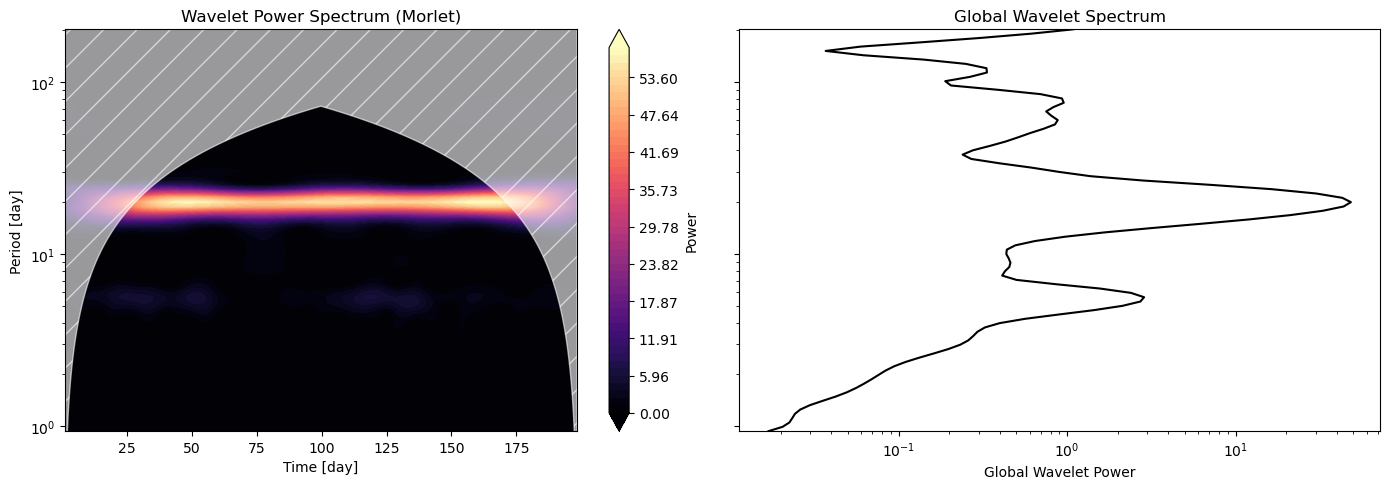

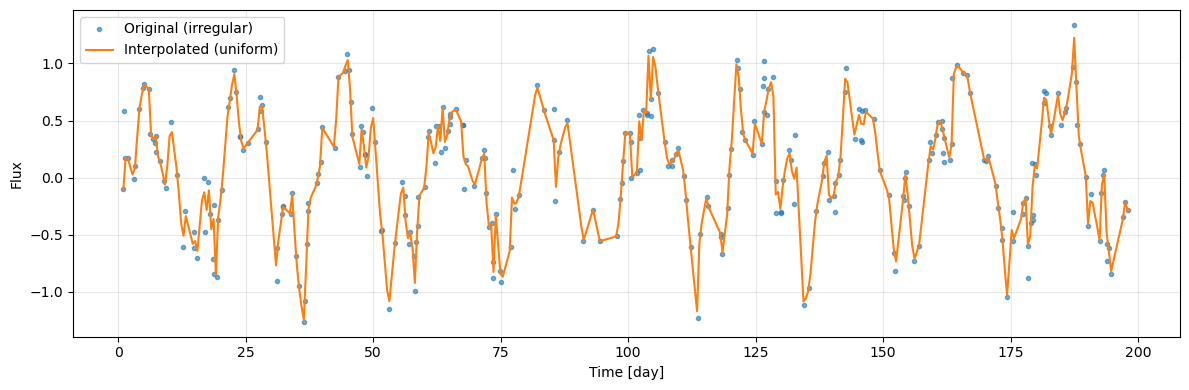

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pycwt as wavelet

# =========================
# 1) 生成模拟不均匀采样光变
# =========================
np.random.seed(42)

# 时间：不均匀采样（0-200天）
t = np.sort(200 * np.random.rand(300))

# 真实信号：主周期 + 次周期 + 漂移
main_period = 20.0
sub_period  = 5.5
trend = 0.001 * (t - np.mean(t))
signal = (
    0.6 * np.sin(2 * np.pi * t / main_period)
    + 0.3 * np.sin(2 * np.pi * t / sub_period + 1.2)
    + trend
)

# 噪声：混合高斯 + 红噪声（1/f^alpha）
alpha = 1.0
dt_med = np.median(np.diff(t))  # 用中位间隔定义一个“代表性dt”
freqs = np.fft.rfftfreq(len(t), d=dt_med)
psd = 1.0 / (freqs + 1e-3) ** alpha
phase = np.exp(2j * np.pi * np.random.rand(len(freqs)))
red_noise = np.fft.irfft(np.sqrt(psd) * phase, n=len(t))

# 把 red_noise 拉伸/对齐到 t 的长度（这里其实已是len(t)，保留你的风格）
red_noise = np.interp(
    np.linspace(0, len(red_noise) - 1, len(t)),
    np.arange(len(red_noise)),
    red_noise
)

noise = 0.3 * red_noise + 0.2 * np.random.randn(len(t))
y = signal + noise

# =========================
# 2) 将不均匀采样插值到等间隔网格（CWT需要）
# =========================
dt = np.median(np.diff(t))
t_uniform = np.arange(t.min(), t.max() + dt, dt)
y_uniform = np.interp(t_uniform, t, y)

# 标准化（和你CWT代码一致）
flux = y_uniform
flux = flux - np.mean(flux)
flux = flux / np.std(flux)

# =========================
# 3) CWT 参数
# =========================
mother = wavelet.Morlet(6)
dj = 1/12
s0 = 2 * dt
J = int(np.log2(len(flux) * dt / s0) / dj)

# =========================
# 4) CWT
# =========================
wave, scales, freqs_cwt, coi, fft, fftfreqs = wavelet.cwt(
    flux, dt, dj=dj, s0=s0, J=J, wavelet=mother
)

power = np.abs(wave) ** 2
period = 1.0 / freqs_cwt

# Meshgrid
T, P = np.meshgrid(t_uniform, period)

# =========================
# 5) 画图：WPS + GWS
# =========================
fig = plt.figure(figsize=(14, 5))

# ---- 左：WPS ----
ax1 = fig.add_subplot(121)

levels = np.linspace(power.min(), power.max(), 50)
im = ax1.contourf(T, P, power, levels=levels, extend="both", cmap="magma")

# COI遮罩：coi 是每个时间点对应的“COI周期上界”（> coi 的区域不可靠）
ax1.fill_between(
    t_uniform,
    period.max(),
    coi,
    color="white",
    alpha=0.6,
    hatch="/"
)

ax1.set_yscale("log")
ax1.set_ylim(period.min(), period.max())
ax1.set_xlabel("Time [day]")
ax1.set_ylabel("Period [day]")
ax1.set_title("Wavelet Power Spectrum (Morlet)")

cbar = fig.colorbar(im, ax=ax1)
cbar.set_label("Power")

# ---- 右：GWS（共享y轴）----
ax2 = fig.add_subplot(122, sharey=ax1)

GWS = np.mean(power, axis=1)  # 对时间平均 -> (Np,)
ax2.plot(GWS, period, color="black")
ax2.set_xscale("log")
ax2.set_xlabel("Global Wavelet Power")
ax2.set_title("Global Wavelet Spectrum")
plt.setp(ax2.get_yticklabels(), visible=False)

plt.tight_layout()
plt.show()

# =========================
# 6) （可选）看看原始不均匀采样 vs 插值后的等间隔
# =========================
plt.figure(figsize=(12, 4))
plt.plot(t, y, "o", ms=3, alpha=0.6, label="Original (irregular)")
plt.plot(t_uniform, y_uniform, "-", lw=1.5, label="Interpolated (uniform)")
plt.xlabel("Time [day]")
plt.ylabel("Flux")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 根据生成模拟光变的代码，应该在20d和5.5d显示周期


In [ ]:
# CWT的好处是给了一个2D的图，如果一段很长时间的光变曲线只在某一段窗口期内有周期，这样在2D图上很容易看出来

### 显著性检验

In [ ]:
# 从上面的CWT 2D图和GWS图上，都能看到20d左右和5.5左右有峰，但是不足以说明这里确实有周期
# 周期信号强度是相对的，一些红噪声也会在CWT图上形成周期，想要说明周期信号的强度，需要进行显著性检验
# 显著性检验方法：1. 古早的AR(1)方法（Torrence & Compo 1998）不过这种方法因为低估红噪声，使用比较少了
#                2.MCMC模拟，根据先验的红噪声模型/观测光变曲线，生成大量模拟光变，计算模拟光变的功率谱，如果观测的功率显著高于大部分模拟的，就说明有显著信号


In [ ]:
#

## 实例分析2 Fermi mkn421

# Method3 Gaussion Process

## Method3 高斯过程 GP
> **不用先把数据变到频域找峰**，而是直接在时域里写一个“如果信号真的含有（准）周期，它在任意两时刻之间应当如何相关”的概率模型；然后用数据去反推这个相关结构里是否需要一个（准）周期成分。

### 1) GP 拟合时间序列的基本原理：把“函数”当随机变量

设你观测到不均匀采样的光变 $y_i\equiv y(t_i)$，带测量误差 $\sigma_i$。

GP 回归把**真实（潜在）信号函数** (f(t)) 视为一个随机函数：
$$
f(t)\sim \mathcal{GP}\big(m(t),,k(t,t')\big),
$$
观测模型：
$$
y_i = f(t_i) + \epsilon_i,\quad \epsilon_i\sim \mathcal{N}(0,\sigma_i^2).
$$

于是整段数据向量 $\mathbf{y}$ 的联合分布是一个多元高斯：
$$
\mathbf{y}\sim \mathcal{N}\left(\mathbf{m},,\mathbf{K}+\mathbf{\Sigma}\right),
$$
其中 $\mathbf{K}_{ij}=k(t_i,t_j))，(\mathbf{\Sigma}=\mathrm{diag}(\sigma_i^2)$。

**关键：核函数 $k(t,t')$ 决定了“什么形状的变化是先验上可能的”。**
要找周期/QPO，就让核函数**内置**周期/准周期结构。


### 2) 周期信号的 GP 核：为什么“周期”能写进协方差

一个严格周期函数的特征是：
若 $t$ 和 $t'$ 相差 $P$ 的整数倍，则函数值高度相关。

最常用的严格周期核（periodic kernel）是：
$$
k_{\rm per}(\tau)=A^2\exp\left[-\frac{2\sin^2(\pi\tau/P)}{\ell^2}\right],\quad \tau=t-t'.
$$

直觉解释：

* $\sin^2(\pi\tau/P)$ 在 $\tau=nP$ 时为 0 → 相关性最大；
* $\ell$ 控制“每个周期内允许多不规则”（$\ell$ 小 → 更接近正弦；$\ell$ 大 → 周期内形状更自由）；
* 这个核等价于“无限多谐波的加权叠加”，所以它能拟合非纯正弦的周期形状（但仍严格周期）。

这类核在天体时序里很常见（比如恒星自转）。([pyorbit.readthedocs.io](https://pyorbit.readthedocs.io/gaussian_process/quasiperiodic_kernel/?utm_source=chatgpt.com))



### 3) 准周期（QPO）的 GP 核：周期性 + 有限相干时间

QPO 的典型特点是：**有个中心周期，但相位/幅度会漂移，过很久就不再保持严格锁相**。
GP 里最常用的做法是：在周期核外面再乘一个衰减项，让“相干性”随时间差变弱：

#### 3.1 最经典：Quasi-Periodic (QP) kernel

$$
k_{\rm qp}(\tau)=A^2
\exp\left[-\frac{\tau^2}{2\lambda^2}\right]
\exp\left[-\frac{2\sin^2(\pi\tau/P)}{\ell^2}\right].
$$

* $P$：准周期中心周期（你真正关心的）
* $\lambda$：**相干时间**（$\tau\gg \lambda$ 时相关性衰减，表示 QPO 不会永久保持）
* $\ell$：周期内形状的“平滑度/谐波含量”
* $A$：振幅规模

这就是很多论文里说的“QP kernel / quasi-periodic GP”。([OUP Academic](https://academic.oup.com/mnras/article/515/4/5251/6651396?utm_source=chatgpt.com))

> 你可以把它理解成：**一个会逐渐“忘记相位”的周期过程**。


### 4) 另一条主流路线：用“阻尼谐振子（SHO）核”表示 QPO（celerite 常用）

在很多天体 QPO 论文里（尤其要快、要可扩展），会用 celerite/tinygp 体系里的 **stochastically-driven damped harmonic oscillator (SHO)** 核来表示“一个在频域上有窄峰的随机振荡分量”。([Celerite](https://celerite.readthedocs.io/en/stable/?utm_source=chatgpt.com))

它的参数通常写成：

* $\omega_0$：中心角频率（对应周期 $P=2\pi/\omega_0$）
* $Q$：品质因数（越大峰越窄、越“像周期”）
* $S_0$ 或等价幅度参数：控制峰高度/功率

直觉上：

* **QPO ≈ 一个被随机激发、又被阻尼的振荡器**
* $Q$ 就是“准周期的相干程度”（和“峰宽”一一对应）

这条路线在“把红噪声 + QPO 窄峰”同时建模时非常自然。


### 5) GP 如何“检测”QPO：拟合 + 模型比较（构建模型显著性）

光靠拟合出一个 $P$ 的后验峰还不够，你需要回答：

> “加入 QPO 核之后，模型提升是否显著，还是红噪声+采样窗口就能解释？”

标准做法是建两个（或多个）模型：

* **噪声模型 $M_0$**：例如红噪声（Matérn、OU/DRW、或 celerite 的 aperiodic SHO/混合项）+ 测量误差
* **含 QPO 的模型 $M_1$**：$M_0$ +（QP 核 或 SHO-QPO 项）

然后比较：

#### 5.1 贝叶斯证据 / Bayes factor（最“正统”）

比较边际似然（evidence）：
$$
\mathcal{Z}=\int p(\mathbf{y}\mid\theta),p(\theta),d\theta,
\quad
B_{10}=\mathcal{Z}_1/\mathcal{Z}_0.
$$
需要 nested sampling 等方法，计算更重，但解释最清晰。

#### 5.2 似然比 / 信息准则（更快但要小心）

* $\Delta \log \mathcal{L}$、AIC/BIC、或交叉验证（LOO-CV）
* 注意：QPO 参数空间常有多峰（不同 $P$），而且边界条件会让经典渐近定理不那么可靠，所以很多严谨论文会用仿真校准阈值。([NASA Technical Reports Server][4])

#### 5.3 最稳健的“p 值”路线：用仿真做 global calibration（和你做 MC-CWT 类似）

* 在 $M_0$（只有红噪声）下生成大量模拟光变
* 每条模拟都做同样的 GP 模型比较（或看“最优 QPO 强度/最大 $\Delta\log\mathcal{L}$”）
* 真实数据的统计量落在模拟分布的哪个分位数 → global 显著性

这能自动处理 **多重试验（period 扫描）** 和采样窗口效应。


### 6) GP 一些特点 

1. **天然适配不均匀采样**：核只需要 $t_i,t_j$，不用重采样（CWT 往往要插值/重采样）。
2. **能把“红噪声 + QPO”写成一个统一概率模型**，避免“先去趋势/先滤波”带来的偏差。([NASA Technical Reports Server][4])
3. **QPO 的“相干时间/品质因数”是模型参数**：$\lambda$ 或 $Q$ 直接量化“准周期程度”。
4. **输出的是后验分布**：你得到的不只是一个周期点估计，而是 $P$ 的不确定度、是否多峰、与噪声参数的相关性。

---

### GP检验QPO流程
>**建 $M_0$(红噪声) 与 $M_1$(红噪声+QPO核) → 采样/优化得到后验 → 用 evidence/预测/似然比比较 → 用 $M_0$ 仿真校准 trials 得到 global 显著性 → 报告 $P$、相干性和全局显著性。**

#### 1) 数据准备

* 输入：不均匀采样 $t_i$、观测 $y_i$、测量误差 $\sigma_i$
* 预处理：

  * 去均值/去趋势（可选，但要小心：别把低频红噪声当趋势硬减掉）
  * 明确误差模型：通常是独立高斯噪声（$\sigma_i$ 已知）+ 可能的额外“jitter”


#### 2) 设定候选模型（关键）

至少两类模型：

###### 模型 $M_0$：只有背景噪声（null）

$$
y(t)=m(t)+g_{\rm noise}(t)+\epsilon
$$

* $m(t)$：均值/缓慢变化（常数、线性、或低频核）
* $g_{\rm noise}$：红噪声核（常见选项）

  * DRW/OU（指数核）
  * Matérn（如 $\nu=3/2,5/2$）
  * celerite 的 aperiodic 组件（更快）

###### 模型 $M_1$：背景噪声 + QPO（alternative）

$$
y(t)=m(t)+g_{\rm noise}(t)+g_{\rm qpo}(t)+\epsilon
$$
QPO 核常见两条路线（二选一即可）：

* **QP kernel（准周期核）**：周期性 × 相干衰减（参数直接给 $P$ 和相干时间 $\lambda$）
* **SHO（阻尼谐振子）核**：参数给中心频率 $\omega_0$（周期）和品质因数 $Q$（峰宽/相干）

> 实操建议：blazar/γ-ray 这类红噪声很强的对象，$M_0$ 的背景核要选得“够红”，否则 QPO 会被误检。


#### 3) 设定先验（避免“自动捏出周期”）

对 QPO 相关参数给**物理/观测合理**的先验范围：

* 周期 $P$：限制在数据跨度与采样能力允许的区间

  * $P_{\min}$ 不要小于典型采样间隔的几倍
  * $P_{\max}$ 不要接近总时长（否则和趋势/低频混淆）
* 相干时间 $\lambda$ 或 $Q$：避免过小（否则其实是噪声）或无限大（退化为严格周期）
* 幅度/功率参数：用对数先验或半正态常见
* jitter：半正态/对数先验，吸收未建模噪声


#### 4) 拟合与推断

对每个模型做超参数推断（两种常见方式）：

* **MAP + 局部近似**：快，但容易掉进局部最优（尤其 period 多峰）
* **MCMC / nested sampling**：更稳（能处理 $P$ 多峰），也能直接做证据（evidence）

实际经验：

* 周期参数几乎总是多峰（好多“谐波/别名解”），用多起点优化或采样更靠谱。


#### 5) “检验”QPO：模型比较（这一步才是显著性）

常用三档，从严谨到省算力：

##### A) 贝叶斯证据 / Bayes factor（最正统）

比较 $Z_1/Z_0$ 或 $\Delta \ln Z$。优点是天然惩罚复杂度。

##### B) 预测能力（交叉验证/LOO）

看加入 QPO 后对留出数据的预测是否提升，避免纯拟合优度幻觉。

##### C) 似然比/AIC/BIC（快但要校准）

$\Delta \log\mathcal{L}$、AIC/BIC 可以用，但**建议配合仿真校准阈值**（因为周期扫描带 trials、多峰、边界效应会让渐近理论不太准）。


#### 6) 处理 trials：做“global”显著性（强烈推荐）

如果你允许 $P$ 在一大段范围里自由搜索，本质上你做了“很多次尝试”。最稳健做法：

1. 用 $M_0$（无 QPO）拟合得到背景噪声参数（或从其后验抽样）
2. 从 $M_0$ 生成很多条模拟光变（保持同样的 $t_i,\sigma_i$）
3. 对每条模拟重复完整搜索，记录统计量（例如最大 $\Delta \ln Z$ 或最大 $\Delta \log\mathcal{L}$）
4. 真实数据的统计量在这个分布中的分位数 → **global p-value / global σ**

这一步相当于你在 CWT/LS 里做的 “max over time×period”的 MC 校准，只是统计量换成了 GP 的模型比较量。


#### 7) 事后诊断与报告（避免“看起来像但其实不是”）

* 检查残差是否还像红噪声（有没有结构没被模型吸收）
* 后验预测检验（posterior predictive check）
* 报告：

  * $P$ 的后验（是否单峰、可信区间）
  * 相干参数（$\lambda$ 或 $Q$）
  * 模型比较结果（$\Delta \ln Z$ 或 global p-value）
  * 对别名/谐波的讨论（是否有多个周期解）



In [ ]:
# 实操
# 1. 数据准备：生成带红噪声的模拟光变
# 2. 模型准备：M0 red noise + white noise 
#             M1 red noise + QPO + white noise （使用celerite2包）
# 3. 模型检验：计算对数似然/BIC 评估M0和M1的接受度

==== Fit results ====
M0 logL = -282.686, BIC = 582.48
M1 logL = -244.156, BIC = 522.54
ΔlogL = 38.530
ΔBIC = -59.95  (negative favors M1)
QPO best-fit period ~ 19.988 days


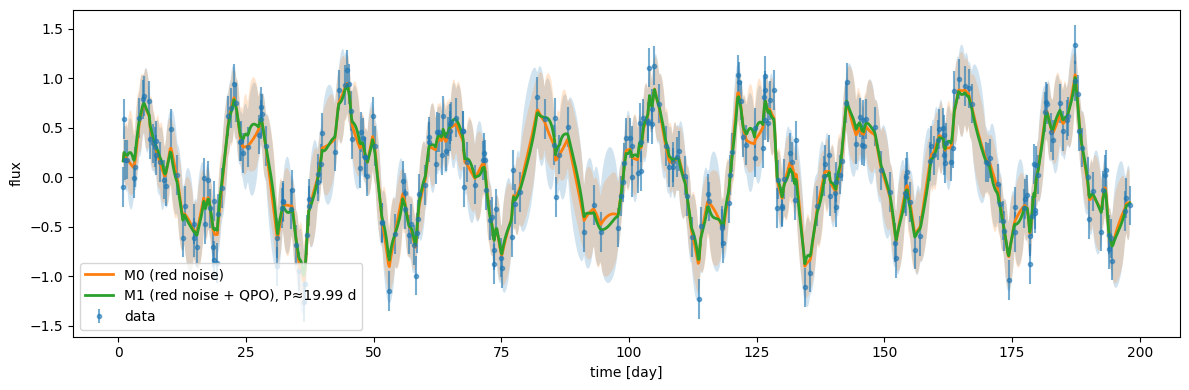

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

from celerite2 import GaussianProcess
from celerite2 import terms

# ============================================================
# 0) 模拟数据（保持不变）
# ============================================================
np.random.seed(42)

t = np.sort(200 * np.random.rand(300))

main_period = 20.0
sub_period  = 5.5
trend = 0.001 * (t - np.mean(t))
signal = (
    0.6 * np.sin(2 * np.pi * t / main_period)
    + 0.3 * np.sin(2 * np.pi * t / sub_period + 1.2)
    + trend
)

alpha = 1.0
dt_med = np.median(np.diff(t))
freqs = np.fft.rfftfreq(len(t), d=dt_med)
psd = 1.0 / (freqs + 1e-3) ** alpha
phase = np.exp(2j * np.pi * np.random.rand(len(freqs)))
red_noise = np.fft.irfft(np.sqrt(psd) * phase, n=len(t))
red_noise = np.interp(np.linspace(0, len(red_noise) - 1, len(t)),
                      np.arange(len(red_noise)), red_noise)

noise = 0.3 * red_noise + 0.2 * np.random.randn(len(t))
y = signal + noise

# 演示用误差
yerr = 0.2 * np.ones_like(y)

# 标准化（提高数值稳定性）
y_mean = np.mean(y)
y_std  = np.std(y)
yn = (y - y_mean) / y_std
yerrn = yerr / y_std

# ============================================================
# 1) 构建模型：M0(红噪声) vs M1(红噪声+QPO)
#    这里用 "jitter 加到 yerr 里" 来替代 JitterTerm
# ============================================================
def compute_gp(kernel, log_jit):
    jit = np.exp(log_jit)  # jitter in normalized units
    yerr_eff = np.sqrt(yerrn**2 + jit**2)

    gp = GaussianProcess(kernel, mean=0.0)
    gp.compute(t, yerr=yerr_eff)
    return gp

def build_gp_M0(params):
    """
    M0: red noise (RealTerm) + jitter (in yerr)
    params = [log_a_rn, log_c_rn, log_jit]
    """
    log_a_rn, log_c_rn, log_jit = params
    a_rn = np.exp(log_a_rn)
    c_rn = np.exp(log_c_rn)

    kernel = terms.RealTerm(a=a_rn, c=c_rn)
    return compute_gp(kernel, log_jit)

def build_gp_M1(params):
    """
    M1: red noise + QPO(damped cosine via ComplexTerm) + jitter(in yerr)
    params = [log_a_rn, log_c_rn, log_a_qpo, log_c_qpo, log_f_qpo, log_jit]
    """
    log_a_rn, log_c_rn, log_a_qpo, log_c_qpo, log_f_qpo, log_jit = params

    a_rn  = np.exp(log_a_rn)
    c_rn  = np.exp(log_c_rn)

    a_qpo = np.exp(log_a_qpo)
    c_qpo = np.exp(log_c_qpo)

    f_qpo = np.exp(log_f_qpo)      # cycles/day
    d_qpo = 2.0 * np.pi * f_qpo    # rad/day

    kernel_rn  = terms.RealTerm(a=a_rn, c=c_rn)
    kernel_qpo = terms.ComplexTerm(a=a_qpo, b=0.0, c=c_qpo, d=d_qpo)
    kernel = kernel_rn + kernel_qpo

    return compute_gp(kernel, log_jit)

def nll_M0(params):
    gp = build_gp_M0(params)
    return -gp.log_likelihood(yn)

def nll_M1(params):
    gp = build_gp_M1(params)
    return -gp.log_likelihood(yn)

# ============================================================
# 2) 多起点优化（周期问题多峰，必须这样做更稳）
# ============================================================
def fit_model(nll, x0_list, bounds):
    best = None
    for x0 in x0_list:
        sol = minimize(nll, x0, method="L-BFGS-B", bounds=bounds)
        if (best is None) or (sol.fun < best.fun):
            best = sol
    return best

# ---- M0 初值/边界 ----
x0_M0_list = [
    np.log([0.5, 1.0, 0.05]),
    np.log([0.2, 0.5, 0.02]),
    np.log([1.0, 2.0, 0.10]),
]
bounds_M0 = [
    (np.log(1e-6), np.log(1e2)),   # a_rn
    (np.log(1e-3), np.log(1e3)),   # c_rn
    (np.log(1e-6), np.log(1e0)),   # jit (normalized units)
]

# ---- M1 初值/边界 ----
Tspan = t.max() - t.min()
fmin = 1.0 / Tspan
fmax = 0.5 / dt_med  # 粗上限

x0_M1_list = [
    np.log([0.5, 1.0, 0.3, 0.3, 1/20.0, 0.05]),  # 20 d
    np.log([0.5, 1.0, 0.2, 0.5, 1/5.5,  0.05]),  # 5.5 d
    np.log([0.2, 0.5, 0.2, 0.2, 1/30.0, 0.02]),  # 30 d
]
bounds_M1 = [
    (np.log(1e-6), np.log(1e2)),          # a_rn
    (np.log(1e-3), np.log(1e3)),          # c_rn
    (np.log(1e-6), np.log(1e2)),          # a_qpo
    (np.log(1e-3), np.log(1e3)),          # c_qpo
    (np.log(fmin), np.log(fmax)),         # f_qpo
    (np.log(1e-6), np.log(1e0)),          # jit
]

sol0 = fit_model(nll_M0, x0_M0_list, bounds_M0)
sol1 = fit_model(nll_M1, x0_M1_list, bounds_M1)

# ============================================================
# 3) 模型比较：logL + BIC
# ============================================================
def bic(logL, k, n):
    return k*np.log(n) - 2*logL

logL0 = -sol0.fun
logL1 = -sol1.fun
k0 = len(sol0.x)
k1 = len(sol1.x)
n  = len(t)

BIC0 = bic(logL0, k0, n)
BIC1 = bic(logL1, k1, n)

print("==== Fit results ====")
print(f"M0 logL = {logL0:.3f}, BIC = {BIC0:.2f}")
print(f"M1 logL = {logL1:.3f}, BIC = {BIC1:.2f}")
print(f"ΔlogL = {logL1-logL0:.3f}")
print(f"ΔBIC = {BIC1-BIC0:.2f}  (negative favors M1)")

# QPO 周期
_, _, _, _, log_f_qpo, _ = sol1.x
P_qpo_hat = 1.0 / np.exp(log_f_qpo)
print(f"QPO best-fit period ~ {P_qpo_hat:.3f} days")

# ============================================================
# 4) 可视化：posterior mean ± 2σ
# ============================================================
gp0 = build_gp_M0(sol0.x)
gp1 = build_gp_M1(sol1.x)

t_pred = np.linspace(t.min(), t.max(), 1200)

mu0, var0 = gp0.predict(yn, t_pred, return_var=True)
mu1, var1 = gp1.predict(yn, t_pred, return_var=True)

# 反标准化回原始尺度
mu0 = mu0*y_std + y_mean
mu1 = mu1*y_std + y_mean
std0 = np.sqrt(var0)*y_std
std1 = np.sqrt(var1)*y_std

plt.figure(figsize=(12,4))
plt.errorbar(t, y, yerr=yerr, fmt=".", alpha=0.6, label="data")
plt.plot(t_pred, mu0, lw=2, label="M0 (red noise)")
plt.fill_between(t_pred, mu0-2*std0, mu0+2*std0, alpha=0.2)
plt.plot(t_pred, mu1, lw=2, label=f"M1 (red noise + QPO), P≈{P_qpo_hat:.2f} d")
plt.fill_between(t_pred, mu1-2*std1, mu1+2*std1, alpha=0.2)
plt.legend()
plt.xlabel("time [day]")
plt.ylabel("flux")
plt.tight_layout()
plt.show()


> GP靠最大拟然接受QPO假设，因为最大拟然只有一个点，所以每次也只能接受最大周期显著的地方，这里就是20ds

N=74  Tspan=2190.000 d  dt_med=30.000 d  err_floor=3.4e-09
Search period range: [150.000, 1000.000] days
==== Fit results ====
M0 logL = -104.340, BIC = 221.59
M1 logL = -83.830, BIC = 193.49
ΔlogL = 20.510
ΔBIC = -28.11  (negative favors M1)
QPO best-fit period ~ 1000.000 days


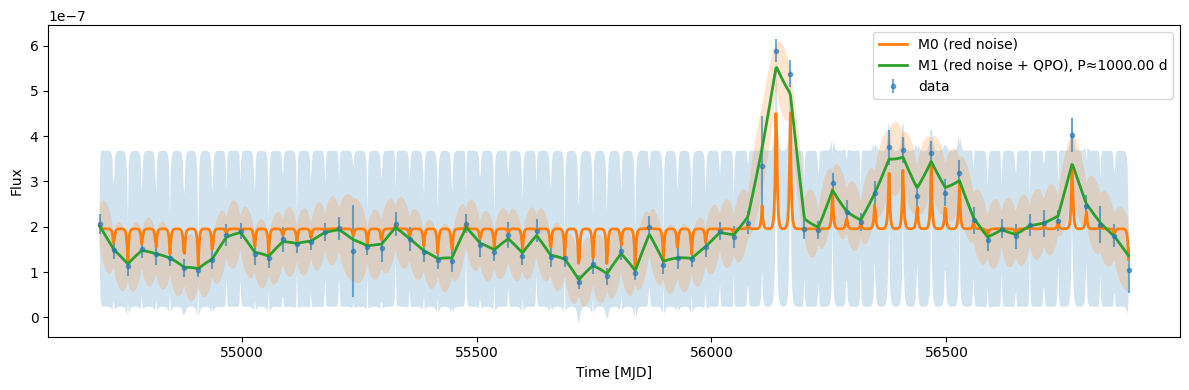

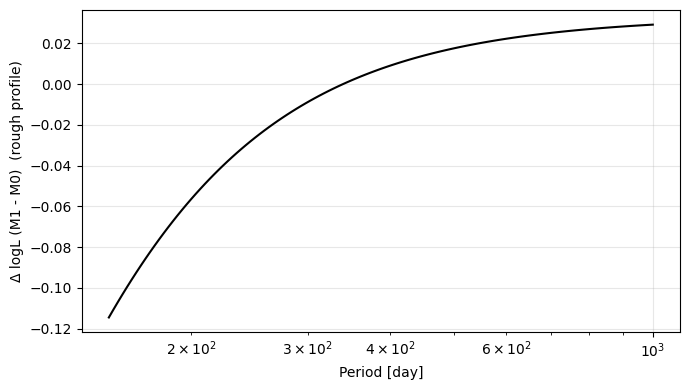

In [1]:
# ============================================================
# GP-QPO detection (Fermi light curve) -- robust version
# ============================================================
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from celerite2 import GaussianProcess, terms

# ------------------------------------------------------------
# 0) Load Fermi light curve
# ------------------------------------------------------------
path = '/home/server/projects/PQO/mkn421/mkn421/4fgl_j1104.4+3812_lightcurve.fits'
hdul = fits.open(path)
lc = hdul[1].data

t_met = 0.5 * (lc['tmin'] + lc['tmax'])
t_mjd = t_met / 86400.0 + 51910.0  # MET -> MJD (days)

flux = lc['flux']
flux_err = lc['flux_err']

# ------------------------------------------------------------
# 1) Clean + sort + merge duplicate timestamps + error floor
# ------------------------------------------------------------
def clean_and_merge(t, y, yerr):
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    yerr = np.asarray(yerr, dtype=float)

    # Keep finite and positive error
    m = np.isfinite(t) & np.isfinite(y) & np.isfinite(yerr) & (yerr > 0)
    t, y, yerr = t[m], y[m], yerr[m]

    # Sort by time
    s = np.argsort(t)
    t, y, yerr = t[s], y[s], yerr[s]

    # Merge duplicates (exact equal)
    uniq_t, idx_start = np.unique(t, return_index=True)
    if len(uniq_t) == len(t):
        return t, y, yerr

    y_new = np.empty_like(uniq_t, dtype=float)
    e_new = np.empty_like(uniq_t, dtype=float)

    for k in range(len(uniq_t)):
        i0 = idx_start[k]
        i1 = idx_start[k+1] if (k+1 < len(uniq_t)) else len(t)
        w = 1.0 / (yerr[i0:i1] ** 2)
        y_new[k] = np.sum(w * y[i0:i1]) / np.sum(w)
        e_new[k] = np.sqrt(1.0 / np.sum(w))

    return uniq_t, y_new, e_new

t, y, yerr = clean_and_merge(t_mjd, flux, flux_err)

# Optional: if you *really* want flux>0 only, uncomment:
# mpos = y > 0
# t, y, yerr = t[mpos], y[mpos], yerr[mpos]

# Error floor to prevent near-singular K+Sigma
err_floor = np.percentile(yerr, 5) * 0.2
if not np.isfinite(err_floor) or err_floor <= 0:
    err_floor = np.median(yerr) * 0.05
yerr = np.sqrt(yerr**2 + err_floor**2)

# Basic stats
dt = np.diff(t)
dt_med = np.median(dt[dt > 0]) if np.any(dt > 0) else np.nan
Tspan = t.max() - t.min()
print(f"N={len(t)}  Tspan={Tspan:.3f} d  dt_med={dt_med:.3f} d  err_floor={err_floor:.3g}")

# Standardize for stability
y_mean = np.mean(y)
y_std  = np.std(y)
yn = (y - y_mean) / y_std
yerrn = yerr / y_std

# ------------------------------------------------------------
# 2) Define GP models: M0 (red noise) vs M1 (red noise + QPO)
#    Use jitter by inflating yerr (no JitterTerm in celerite2 terms)
# ------------------------------------------------------------
def compute_gp(kernel, log_jit):
    jit = np.exp(log_jit)                 # jitter in normalized units
    yerr_eff = np.sqrt(yerrn**2 + jit**2) # always positive
    gp = GaussianProcess(kernel, mean=0.0)
    gp.compute(t, yerr=yerr_eff)
    return gp

def build_gp_M0(params):
    # params = [log_a_rn, log_c_rn, log_jit]
    log_a_rn, log_c_rn, log_jit = params
    a_rn = np.exp(log_a_rn)
    c_rn = np.exp(log_c_rn)
    kernel = terms.RealTerm(a=a_rn, c=c_rn)  # OU-like red noise
    return compute_gp(kernel, log_jit)

def build_gp_M1(params):
    # params = [log_a_rn, log_c_rn, log_a_qpo, log_c_qpo, log_f_qpo, log_jit]
    log_a_rn, log_c_rn, log_a_qpo, log_c_qpo, log_f_qpo, log_jit = params

    a_rn = np.exp(log_a_rn)
    c_rn = np.exp(log_c_rn)

    a_qpo = np.exp(log_a_qpo)
    c_qpo = np.exp(log_c_qpo)

    f_qpo = np.exp(log_f_qpo)       # cycles/day
    d_qpo = 2.0 * np.pi * f_qpo     # rad/day

    kernel_rn  = terms.RealTerm(a=a_rn, c=c_rn)
    kernel_qpo = terms.ComplexTerm(a=a_qpo, b=0.0, c=c_qpo, d=d_qpo)  # damped cosine
    kernel = kernel_rn + kernel_qpo
    return compute_gp(kernel, log_jit)

# Safe NLL to avoid NaNs killing the optimizer
BIG = 1e50

def nll_M0(params):
    try:
        gp = build_gp_M0(params)
        ll = gp.log_likelihood(yn)
        if not np.isfinite(ll):
            return BIG
        return -ll
    except Exception:
        return BIG

def nll_M1(params):
    try:
        gp = build_gp_M1(params)
        ll = gp.log_likelihood(yn)
        if not np.isfinite(ll):
            return BIG
        return -ll
    except Exception:
        return BIG

# ------------------------------------------------------------
# 3) Multi-start optimization with sensible period search window
# ------------------------------------------------------------
def fit_model(nll, x0_list, bounds):
    best = None
    for x0 in x0_list:
        sol = minimize(nll, x0, method="L-BFGS-B", bounds=bounds)
        if (best is None) or (sol.fun < best.fun):
            best = sol
    return best

# --- M0 initial guesses / bounds ---
x0_M0_list = [
    np.log([0.5, 1.0, 0.05]),
    np.log([0.2, 0.5, 0.02]),
    np.log([1.0, 2.0, 0.10]),
]
bounds_M0 = [
    (np.log(1e-8), np.log(1e2)),   # a_rn
    (np.log(1e-4), np.log(1e3)),   # c_rn  (1/day)
    (np.log(1e-8), np.log(1e0)),   # jit
]

# --- Period search range (IMPORTANT) ---
# Avoid letting QPO escape to fmax/fmin:
# - Pmin should be several times dt_med
# - Pmax should be comfortably smaller than Tspan (avoid eating trends)
Pmin = max(5.0 * dt_med, 3.0)          # >= 5 bins-ish (tune if needed)
Pmax = min(0.5 * Tspan, 1000.0)        # <= half-span (tune upper cap)
if Pmax <= Pmin:
    Pmin = max(2.0 * dt_med, 3.0)
    Pmax = max(10.0 * dt_med, Pmin * 2.0)

fmin = 1.0 / Pmax
fmax = 1.0 / Pmin

print(f"Search period range: [{Pmin:.3f}, {Pmax:.3f}] days")

# --- M1 initial guesses / bounds ---
x0_M1_list = [
    np.log([0.5, 1.0, 0.2, 0.2, 1/20.0, 0.05]),
    np.log([0.5, 1.0, 0.2, 0.2, 1/50.0, 0.05]),
    np.log([0.2, 0.5, 0.2, 0.5, 1/200.0, 0.05]),
]
bounds_M1 = [
    (np.log(1e-8), np.log(1e2)),          # a_rn
    (np.log(1e-4), np.log(1e3)),          # c_rn
    (np.log(1e-8), np.log(1e2)),          # a_qpo
    (np.log(1e-4), np.log(1e3)),          # c_qpo
    (np.log(fmin), np.log(fmax)),         # f_qpo
    (np.log(1e-8), np.log(1e0)),          # jit
]

sol0 = fit_model(nll_M0, x0_M0_list, bounds_M0)
sol1 = fit_model(nll_M1, x0_M1_list, bounds_M1)

# ------------------------------------------------------------
# 4) Model comparison: logL + BIC
# ------------------------------------------------------------
def bic(logL, k, n):
    return k*np.log(n) - 2*logL

logL0 = -sol0.fun if np.isfinite(sol0.fun) else np.nan
logL1 = -sol1.fun if np.isfinite(sol1.fun) else np.nan

k0, k1 = len(sol0.x), len(sol1.x)
n = len(t)

BIC0 = bic(logL0, k0, n) if np.isfinite(logL0) else np.nan
BIC1 = bic(logL1, k1, n) if np.isfinite(logL1) else np.nan

print("==== Fit results ====")
print(f"M0 logL = {logL0:.3f}, BIC = {BIC0:.2f}")
print(f"M1 logL = {logL1:.3f}, BIC = {BIC1:.2f}")
print(f"ΔlogL = {logL1-logL0:.3f}")
print(f"ΔBIC = {BIC1-BIC0:.2f}  (negative favors M1)")

# QPO period estimate
if np.isfinite(logL1):
    _, _, _, _, log_f_qpo, _ = sol1.x
    P_qpo_hat = 1.0 / np.exp(log_f_qpo)
    print(f"QPO best-fit period ~ {P_qpo_hat:.3f} days")
else:
    P_qpo_hat = np.nan
    print("QPO best-fit period: NaN (fit failed)")

# ------------------------------------------------------------
# 5) Visualization: posterior mean ± 2σ
# ------------------------------------------------------------
if np.isfinite(logL0):
    gp0 = build_gp_M0(sol0.x)
else:
    gp0 = None

if np.isfinite(logL1):
    gp1 = build_gp_M1(sol1.x)
else:
    gp1 = None

t_pred = np.linspace(t.min(), t.max(), 1200)

plt.figure(figsize=(12,4))
plt.errorbar(t, y, yerr=yerr, fmt=".", alpha=0.6, label="data")

if gp0 is not None:
    mu0, var0 = gp0.predict(yn, t_pred, return_var=True)
    mu0 = mu0*y_std + y_mean
    std0 = np.sqrt(var0)*y_std
    plt.plot(t_pred, mu0, lw=2, label="M0 (red noise)")
    plt.fill_between(t_pred, mu0-2*std0, mu0+2*std0, alpha=0.2)

if gp1 is not None:
    mu1, var1 = gp1.predict(yn, t_pred, return_var=True)
    mu1 = mu1*y_std + y_mean
    std1 = np.sqrt(var1)*y_std
    plt.plot(t_pred, mu1, lw=2, label=f"M1 (red noise + QPO), P≈{P_qpo_hat:.2f} d")
    plt.fill_between(t_pred, mu1-2*std1, mu1+2*std1, alpha=0.2)

plt.legend()
plt.xlabel("Time [MJD]")
plt.ylabel("Flux")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6) Diagnostic: rough profile ΔlogL vs Period
# ------------------------------------------------------------
if gp0 is not None:
    logL0_true = gp0.log_likelihood(yn)

    # Fix RN + jit at M0 best, scan P; fix (a_qpo,c_qpo) at reasonable values
    log_a_rn0, log_c_rn0, log_jit0 = sol0.x
    log_a_qpo_fix = np.log(0.1)
    log_c_qpo_fix = np.log(0.1)

    Ps = np.logspace(np.log10(Pmin), np.log10(Pmax), 120)
    dlogL = []

    for P in Ps:
        f = 1.0 / P
        params = np.array([log_a_rn0, log_c_rn0,
                           log_a_qpo_fix, log_c_qpo_fix,
                           np.log(f),
                           log_jit0])
        try:
            gp = build_gp_M1(params)
            ll = gp.log_likelihood(yn)
            dlogL.append(ll - logL0_true if np.isfinite(ll) else np.nan)
        except Exception:
            dlogL.append(np.nan)

    dlogL = np.array(dlogL)

    plt.figure(figsize=(7,4))
    plt.plot(Ps, dlogL, "k-")
    plt.xscale("log")
    plt.xlabel("Period [day]")
    plt.ylabel("Δ logL (M1 - M0)  (rough profile)")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


> 在真实光变曲线上，GP方法就出现了退化
原则上在300d左右有个不是很显著的周期信号，但是在GP内部假设检验显著性低不通过，因为QPO信号和建模的red niose信号高度耦合，不一定检测出来，这样对于GP来说，为了给出最高显著性的接受M1的方案，模型自然收敛到给定的周期范围的最大值（原则上任何光变都可以有一个无限大的周期）

In [ ]:
> GP和LSP一样，接受的周期是在整个时间段上的，因为建模QPO的kernel是不时间依赖的，也就默认在全时间有周期信号
> 为了解决这种情况，一个可以的方法是对长光变做滑动窗口，分段GP。这样slide window的width和step就是需要考虑的；另一个方法是在kernel里加入时间变化，这样会让拟合变得更复杂
> 总的来说，GP不是非常适合transient QPO检测，一些有时间-周期的2D map更合适

## Method4 Weighted Wavelet Z-Transform

Weighted wavelet Z-transform analysis [Foster 1996](https://ui.adsabs.harvard.edu/abs/1996AJ....112.1709F/abstract)
> 在每一个时间点，用一个局部时间窗，只拟合附近的数据，看看某个频率的正弦在这一小段时间内是否显著存在


###  基本思想（Foster 1996 ）

在每个候选**频率** $\omega$ 和**中心时间** $\tau$ 的邻域内，用**指数权重**（以 $\tau$ 为中心）对数据点加权，只在这片局域上拟合一个**简谐模型**，用“解释方差占比”来衡量该时间–频率处的信号强度。

* **加权函数**（高斯窗/指数窗，常用）：
  $$
  w_i(\tau, \omega) = \exp\big(-c\omega^2(t_i-\tau)^2\big)
  $$
  其中 ( c>0 ) 为**衰减常数**（控制时间–频率分辨率的折中；$\omega$ 越高，窗口越窄）。
* **局域模型**（三参数正弦）：
  $$
  y(t) \approx A\cos\big(\omega t\big) + B\sin\big(\omega t\big) + C
  $$
* 在加权意义下做**线性最小二乘**，得到 $A, B, C$。


###  关键统计量（WWA / WWS / WWZ）

设：

* $N_{\text{eff}}$：在权重下的**有效样本数**（相当于 $\sum w_i$ 的归一化形式）；
* $V_y$：加权总体方差；
* $V_{\text{res}}$：加权残差方差（拟合后剩余的）。

定义：

* **WWA（weighted wavelet amplitude）**：局域拟合的“信号振幅”估计，常取
  $$
  \text{WWA} = \sqrt{A^2 + B^2}
  $$
* **WWS（weighted wavelet power/spectrum）**：信号功率，常用 $\text{WWS} \propto A^2 + B^2$ 或按 $V_y - V_{\text{res}}$ 归一。
* **WWZ（weighted wavelet Z-statistic）**：对比“拟合解释度”（信号）与“残差”（噪声）的**类F统计量**，常见形式为
  $$
  \text{WWZ}(\tau,\omega) = \frac{(N_{\text{eff}}-3)}{2}
  \frac{V_y - V_{\text{res}}}{V_{\text{res}}}
  $$
  直观理解：在 $(\tau,\omega)$上，若简谐模型显著降低了方差（残差小），WWZ 就大，说明有周期信号！

> 注：不同实现里 WWZ 的常数因子/自由度处理略有差异，但“**解释方差/残差**”的思想一致。


### 计算流程（实操步骤）

1. **准备数据**：${t_i, y_i, \sigma_i}$。可先去均值/去趋势，$\sigma_i$ 可转成权重 $w_i \leftarrow w_i/\sigma_i^2$（把测量误差并入）。
2. **网格**：选择一组中心时间 $\tau$（覆盖观测时段）与频率 $\omega$（或周期 $P=2\pi/\omega)$的网格。
3. **权重**：对每个 $(\tau,\omega)$ 计算 $w_i(\tau,\omega)$；若考虑测量误差，使用 $w_i/\sigma_i^2$。
4. **加权回归**：解
   $$
   \min_{A,B,C}\sum_i w_i\big[y_i - (A\cos\omega t_i + B\sin\omega t_i + C)\big]^2
   $$
   得 $A,B,C$ 与加权残差。
5. **统计量**：计算 $N_{\text{eff}}, V_y, V_{\text{res}}$，继而得到 **WWA/WWS/WWZ**。
6. **时–频图**：把 WWZ（或WWS）按 $(\tau,\omega)$ 映射成热力图；并可对每个 $\omega$ 求时间平均，得到“平均功率谱”。


### 超参数选择与物理含义

* **$c$（衰减常数）**：

  * 大$c$：时间窗更窄 → **时间分辨率高**，**频率分辨率低**；
  * 小 $c$：相反。
  * 实务中常从 $c\sim 0.001$–$0.01$ 级别试起，并用注入–恢复（injection–recovery）做灵敏度测试。
* **$\tau$ 网格步长**：过粗会漏掉短暂信号，过细计算量大；可与典型周期、采样间隔匹配。
* **$\omega$（或 P）范围与步长**：低频端需受时间基线限制（至少覆盖数个周期）；高频端受最小采样间隔/测量噪声限制。
* **是否并入 $\sigma_i$**：高噪声点权重变小，更稳健。


### 输出如何解读？

* **WWZ 时–频图**：

  * **亮带/亮斑** = 在该时刻–频率上存在强的准周期信号；
  * 带的**持续时间**代表“可见周期的生命周期”；
  * 带的**弯曲**代表频率随时间漂移（chirp/漂移QPO）；
  * 带的**宽度**（频域）反映 Q 值 $(\nu/\Delta\nu)$。
* **时间平均功率谱（WWZ-mean）**：可与 LSP 对照，检验全时段平均的主峰是否一致。
* **相位/幅度的时间演化**：由 $A(\tau,\omega), B(\tau,\omega)$ 可反推瞬时相位与幅度，辅助做相位连贯性检查。


### 显著性检验（非常关键）

**WWZ 只是“检出量”，不是显著性**。要判断是不是“真QPO”，必须给出 FAP/置信度：

1. **红噪声背景（推荐）**：

   * 先拟合光变的 PSD（幂律/折线幂律）与 PDF（常见为对数正态）；
   * 用 Emmanoulopoulos+2013/DELCgen 生成大量“红噪声”模拟光变（保持不均匀采样与误差）；
   * 对每条模拟数据跑同样的 WWZ，得到**最大WWZ分布**或**某频带的峰值分布**；
   * 实测峰在此分布上的分位数 = (1-)FAP（给**全局显著性**）。
2. **REDFIT式包络**（次优）：

   * 在每个频率上用 AR(1) 背景给出置信包络；
   * 受不均匀采样与非平稳性的影响更大，建议仅作参考。
3. **多重比较**（look-elsewhere）：

   * WWZ在大量 $(\tau,\omega)$ 上扫描，必须进行全局校正（蒙特卡洛天然解决）。


### 8. 与 LSP / 传统小波（Morlet CWT）的对比

| 方面  | LSP        | Morlet CWT | **WWZ**            |
| --- | ---------- | ---------- | ------------------ |
| 采样  | 不均匀友好      | 需均匀（或重采样）  | **原生不均匀友好**        |
| 输出  | 全时段频谱      | 时–频图       | **时–频图**           |
| 功能  | 稳定周期/全局主峰  | 瞬时频率/漂移    | **瞬时频率/漂移 + 回归稳健** |
| 显著性 | 易做（需红噪声修正） | 需MC或解析近似   | **需MC（推荐）**        |
| 速度  | 快          | 中          | 中（取决于网格密度）         |



## 实例分析1 模拟光变


In [ ]:
# WWZ对不均匀光变十分友好，不过为了得到最好的时间分辨率和频率分辨率，需要适当调参
# 和CWT一样，需要做显著性分析

*** Starting Weighted Wavelet Z-transform ***

Pseudo sample frequency (median) is  2.204
largest tau window is  0.99
7.89 seconds has passed to complete Weighted Wavelet Z-transform 



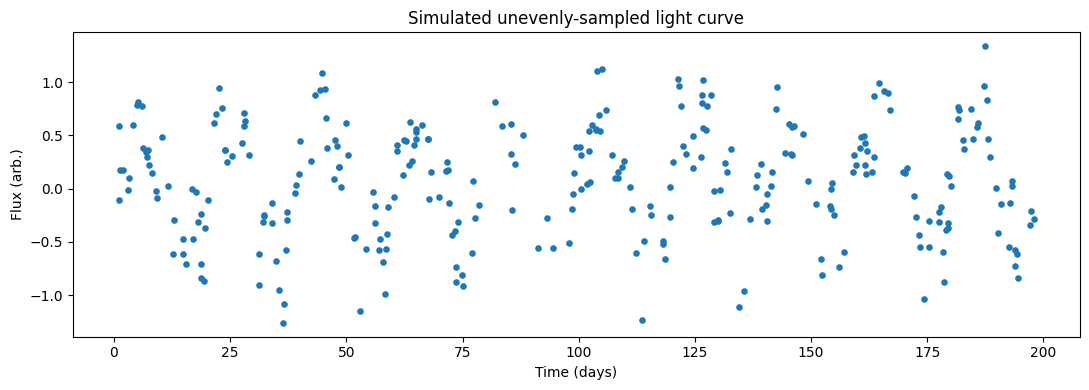

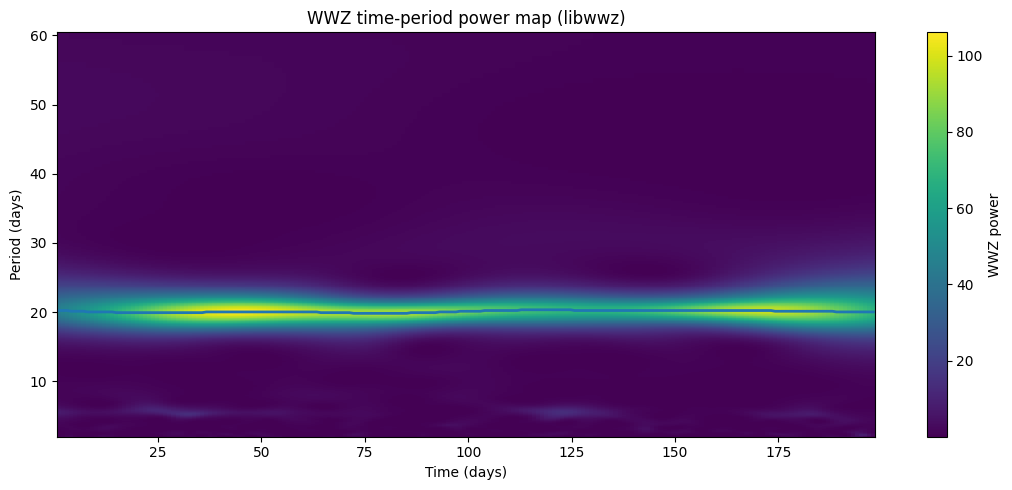

Top 10 ridge peaks (by WWZ power):
 1: tau=  44.57  period= 20.034  power=  106.127
 2: tau=  43.58  period= 20.034  power=  106.090
 3: tau=  45.56  period= 20.034  power=  106.056
 4: tau=  42.59  period= 20.034  power=  105.941
 5: tau=  46.55  period= 20.034  power=  105.883
 6: tau=  41.60  period= 20.034  power=  105.676
 7: tau=  47.54  period= 20.034  power=  105.615
 8: tau=  40.61  period= 20.034  power=  105.293
 9: tau=  48.53  period= 20.034  power=  105.258
10: tau=  49.52  period= 20.034  power=  104.822


In [4]:
# 使用libwwz包
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 0) 你的模拟不均匀采样光变（原样保留）
# =========================
np.random.seed(42)

# 时间：不均匀采样（0-200天）
t = np.sort(200 * np.random.rand(300))

# 真实信号：主周期 + 次周期 + 漂移
main_period = 20.0
sub_period  = 5.5
trend = 0.001 * (t - np.mean(t))
signal = (
    0.6 * np.sin(2 * np.pi * t / main_period)
    + 0.3 * np.sin(2 * np.pi * t / sub_period + 1.2)
    + trend
)

# 噪声：混合高斯 + 红噪声（1/f^alpha）
alpha = 1.0
dt_med = np.median(np.diff(t))  # 用中位间隔定义一个“代表性dt”
freqs = np.fft.rfftfreq(len(t), d=dt_med)
psd = 1.0 / (freqs + 1e-3) ** alpha
phase = np.exp(2j * np.pi * np.random.rand(len(freqs)))
red_noise = np.fft.irfft(np.sqrt(psd) * phase, n=len(t))

# 把 red_noise 拉伸/对齐到 t 的长度
red_noise = np.interp(
    np.linspace(0, len(red_noise) - 1, len(t)),
    np.arange(len(red_noise)),
    red_noise
)

noise = 0.3 * red_noise + 0.2 * np.random.randn(len(t))
y = signal + noise


# =========================
# 1) WWZ：用 libwwz 计算
# =========================
# 安装：
#   pip install libwwz joblib
#
# libwwz 文档：wwt(timestamps, magnitudes, time_divisions, freq_params, decay_constant, method, parallel)
#  - method='linear' 时：freq_params = [freq_low, freq_high, freq_step, override]（override 这个参数在文档里出现，
#    但 wwt 的线性分支实际只用到前三个；多给也不影响你自己写法时的可读性）:contentReference[oaicite:1]{index=1}

from libwwz import wwt  # libwwz 顶层直接暴露 wwt :contentReference[oaicite:2]{index=2}

# --- 频率范围设置（单位：cycles/day，如果你的 t 是“天”）---
# 你信号里有 20d 和 5.5d，所以我们覆盖更宽一点，例如 period 2~60 天：
period_min = 2.0
period_max = 60.0
freq_low  = 1.0 / period_max   # ~0.0167
freq_high = 1.0 / period_min   # 0.5

# 频率步长：越小越细，但越慢。给一个跟总时长 T 相关的经验步长
T = t.max() - t.min()
freq_step = 0.05 / T  # 这个思路也常见于一些 WWZ 工具的示例用法（按总时长定步长）:contentReference[oaicite:3]{index=3}

# tau 网格（time_divisions）：越大时间分辨率越高，但越慢
time_divisions = 200

# 衰减常数 c：libwwz 文档建议 < 0.02（越大时间定位越强、频率分辨率越差）:contentReference[oaicite:4]{index=4}
decay_constant = 0.0125

# 计算 WWZ
out = wwt(
    timestamps=t.astype(float),
    magnitudes=y.astype(float),
    time_divisions=time_divisions,
    freq_params=[freq_low, freq_high, freq_step, True],
    decay_constant=decay_constant,
    method="linear",
    parallel=True
)

tau_mat, freq_mat, wwz_mat, amp_mat, coef_mat, neff_mat = out  # 形状都是 (ntau, nfreq)

# 转成 period（天），更直观
period_mat = 1.0 / freq_mat


# =========================
# 2) 提取 ridge：每个 tau 上 WWZ 最大对应的 period
# =========================
ridge_idx = np.argmax(wwz_mat, axis=1)                 # 每行（固定tau）最大值的列索引
ridge_tau = tau_mat[:, 0]                              # 每行 tau 相同，取第一列即可
ridge_period = period_mat[np.arange(len(ridge_idx)), ridge_idx]
ridge_power = wwz_mat[np.arange(len(ridge_idx)), ridge_idx]


# =========================
# 3) 作图：光变 + WWZ 时频图 + ridge
# =========================
plt.figure(figsize=(11, 4))
plt.scatter(t, y, s=14)
plt.xlabel("Time (days)")
plt.ylabel("Flux (arb.)")
plt.title("Simulated unevenly-sampled light curve")
plt.tight_layout()

plt.figure(figsize=(11, 5))

# pcolormesh 需要 x/y 递增：这里 tau 是递增的，freq 也是递增的；period=1/f 会递减
# 所以我们用 freq 作为纵轴更稳妥，再把右边加个 period 的标尺；或直接把 period 反过来。
# 我这里选择：显示 period，但先把频率轴对应的 period 反向排序，让 period 递增。
sort_idx = np.argsort(period_mat[0, :])  # period 递增的列序（等价于 freq 递减）

tau_plot = tau_mat[:, 0]
period_plot = period_mat[:, sort_idx]
wwz_plot = wwz_mat[:, sort_idx]

# period_plot 每行一样（只和freq有关），取第一行即可
p_axis = period_plot[0, :]

# 网格
TT, PP = np.meshgrid(tau_plot, p_axis, indexing="xy")  # TT shape (nfreq, ntau) after transpose handling

# wwz_plot 是 (ntau, nfreq_sorted)，pcolormesh 需要 (ny, nx)
plt.pcolormesh(tau_plot, p_axis, wwz_plot.T, shading="auto")
plt.xlabel("Time (days)")
plt.ylabel("Period (days)")
plt.title("WWZ time-period power map (libwwz)")
cbar = plt.colorbar()
cbar.set_label("WWZ power")

# 画 ridge（period 上）
plt.plot(ridge_tau, ridge_period, linewidth=2)

plt.tight_layout()
plt.show()


# =========================
# 4)（可选）打印 ridge 的几个最强峰值（粗略看看主周期）
# =========================
topk = 10
idx_sorted = np.argsort(ridge_power)[::-1]
print(f"Top {topk} ridge peaks (by WWZ power):")
for k in range(topk):
    i = idx_sorted[k]
    print(f"{k+1:2d}: tau={ridge_tau[i]:7.2f}  period={ridge_period[i]:7.3f}  power={ridge_power[i]:9.3f}")


> ...

## 实例分析2 Fermi mkn421 LC

N=74, Tspan=2190.00 d, dt_med=30.00 d
WWZ settings:
  period range: [50.0, 500.0] d
  freq range:   [0.002, 0.02] 1/d
  freq_step:    2.28311e-05 1/d
  time_divisions: 250
  decay_constant: 0.0125
*** Starting Weighted Wavelet Z-transform ***

adjusted time_divisions to:  74
Pseudo sample frequency (median) is  0.033
largest tau window is  30.0
0.71 seconds has passed to complete Weighted Wavelet Z-transform 



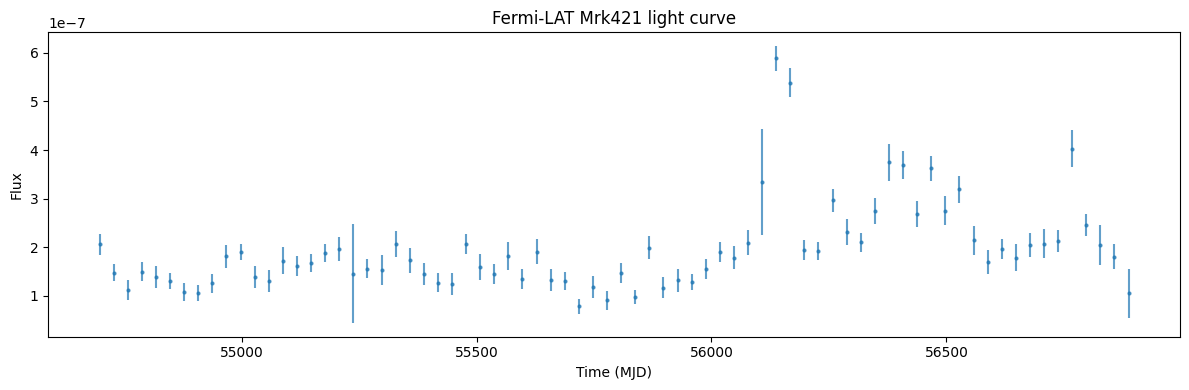

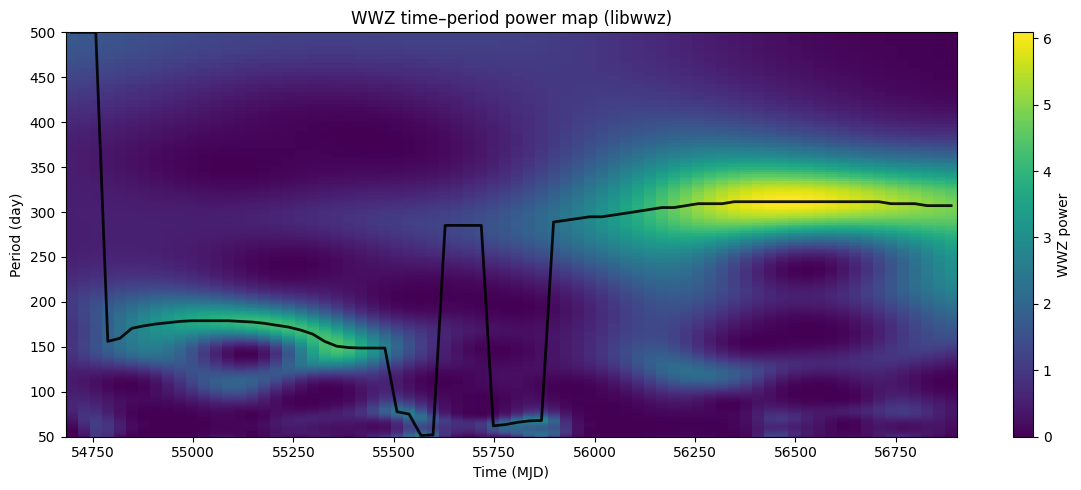

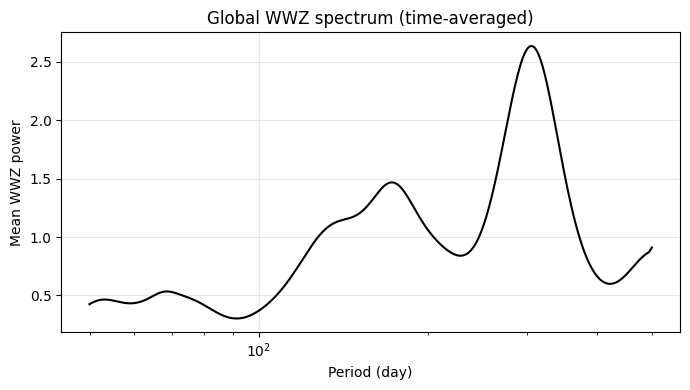

Top 10 ridge peaks (by WWZ power):
 1: tau=  56467.66  period=   311.522  power=       6.088
 2: tau=  56497.66  period=   311.522  power=       6.084
 3: tau=  56437.66  period=   311.522  power=       6.059
 4: tau=  56527.66  period=   311.522  power=       6.051
 5: tau=  56407.66  period=   311.522  power=       5.994
 6: tau=  56557.66  period=   311.522  power=       5.993
 7: tau=  56587.66  period=   311.522  power=       5.915
 8: tau=  56377.66  period=   311.522  power=       5.892
 9: tau=  56617.66  period=   311.522  power=       5.822
10: tau=  56347.66  period=   311.522  power=       5.754


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from libwwz import wwt

# ============================================================
# 0) 读取 Fermi Mrk421 光变
# ============================================================
path = "/home/server/projects/PQO/mkn421/mkn421/4fgl_j1104.4+3812_lightcurve.fits"
hdul = fits.open(path)
lc = hdul[1].data

t_met = 0.5 * (lc["tmin"] + lc["tmax"])
t_mjd = t_met / 86400.0 + 51910.0  # MET -> MJD (days)

flux = lc["flux"].astype(float)
flux_err = lc["flux_err"].astype(float)

# ============================================================
# 1) 清洗 + 排序 + 合并重复时间（推荐，避免 WWZ/GP 数值问题）
# ============================================================
def clean_and_merge(t, y, yerr):
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    yerr = np.asarray(yerr, dtype=float)

    m = np.isfinite(t) & np.isfinite(y) & np.isfinite(yerr) & (yerr > 0)
    t, y, yerr = t[m], y[m], yerr[m]

    s = np.argsort(t)
    t, y, yerr = t[s], y[s], yerr[s]

    uniq_t, idx_start = np.unique(t, return_index=True)
    if len(uniq_t) == len(t):
        return t, y, yerr

    y_new = np.empty_like(uniq_t, dtype=float)
    e_new = np.empty_like(uniq_t, dtype=float)

    for k in range(len(uniq_t)):
        i0 = idx_start[k]
        i1 = idx_start[k+1] if (k+1 < len(uniq_t)) else len(t)
        w = 1.0 / (yerr[i0:i1] ** 2)
        y_new[k] = np.sum(w * y[i0:i1]) / np.sum(w)
        e_new[k] = np.sqrt(1.0 / np.sum(w))

    return uniq_t, y_new, e_new

t, y, yerr = clean_and_merge(t_mjd, flux, flux_err)

Tspan = t.max() - t.min()
dt_med = np.median(np.diff(t))
print(f"N={len(t)}, Tspan={Tspan:.2f} d, dt_med={dt_med:.2f} d")

# ============================================================
# 2) 设定 WWZ 参数（按你的科学问题改这里）
# ============================================================
# 你说你关心 ~300 d 周期，这里给个覆盖范围，比如 150–1000 d
period_min = 50.0
period_max = 500.0
freq_low  = 1.0 / period_max
freq_high = 1.0 / period_min

# 频率步长：经验做法：和总时长成反比
# 步长越小越细，但更慢。可以先粗后细。
freq_step = 0.05 / Tspan

# time_divisions：时间网格数（越大时间分辨率越高，但越慢）
time_divisions = 250

# 衰减常数 c：越大时间定位越强，频率分辨率越差
# 你之前用 0.0125 没问题；周期更长时也可更小一点
decay_constant = 0.0125

print("WWZ settings:")
print(f"  period range: [{period_min}, {period_max}] d")
print(f"  freq range:   [{freq_low:.6g}, {freq_high:.6g}] 1/d")
print(f"  freq_step:    {freq_step:.6g} 1/d")
print(f"  time_divisions: {time_divisions}")
print(f"  decay_constant: {decay_constant}")

# ============================================================
# 3) 计算 WWZ（libwwz）
# ============================================================
out = wwt(
    timestamps=t.astype(float),
    magnitudes=y.astype(float),
    time_divisions=time_divisions,
    freq_params=[freq_low, freq_high, freq_step, True],
    decay_constant=decay_constant,
    method="linear",
    parallel=True
)

tau_mat, freq_mat, wwz_mat, amp_mat, coef_mat, neff_mat = out
period_mat = 1.0 / freq_mat

# ============================================================
# 4) Ridge：每个 tau 上 WWZ 最大对应的 period
# ============================================================
ridge_idx = np.argmax(wwz_mat, axis=1)
ridge_tau = tau_mat[:, 0]
ridge_period = period_mat[np.arange(len(ridge_idx)), ridge_idx]
ridge_power  = wwz_mat[np.arange(len(ridge_idx)), ridge_idx]

# ============================================================
# 5) 作图：光变 + WWZ 时频图 + ridge
# ============================================================
plt.figure(figsize=(12, 4))
plt.errorbar(t, y, yerr=yerr, fmt=".", ms=4, alpha=0.7)
plt.xlabel("Time (MJD)")
plt.ylabel("Flux")
plt.title("Fermi-LAT Mrk421 light curve")
plt.tight_layout()
plt.show()

# 为了让 period 轴递增，我们对列按 period 排序
sort_idx = np.argsort(period_mat[0, :])    # period 递增
tau_plot = tau_mat[:, 0]
period_plot = period_mat[:, sort_idx]
wwz_plot = wwz_mat[:, sort_idx]
p_axis = period_plot[0, :]

plt.figure(figsize=(12, 5))
plt.pcolormesh(tau_plot, p_axis, wwz_plot.T, shading="auto")
plt.xlabel("Time (MJD)")
plt.ylabel("Period (day)")
plt.title("WWZ time–period power map (libwwz)")
cbar = plt.colorbar()
cbar.set_label("WWZ power")

plt.plot(ridge_tau, ridge_period, "k-", lw=2, alpha=0.9)
plt.ylim(period_min, period_max)
plt.tight_layout()
plt.show()

# ============================================================
# 6) （很有用）全局 WWZ spectrum：对时间求平均，看主周期候选
# ============================================================
gwwz = np.nanmean(wwz_mat, axis=0)  # (nfreq,)
period_axis = 1.0 / freq_mat[0, :]

# period 递增排序
p_sort = np.argsort(period_axis)
plt.figure(figsize=(7,4))
plt.plot(period_axis[p_sort], gwwz[p_sort], "k-")
plt.xscale("log")
plt.xlabel("Period (day)")
plt.ylabel("Mean WWZ power")
plt.title("Global WWZ spectrum (time-averaged)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# 7) 打印 ridge 的最强若干点（粗看哪些时段最强）
# ============================================================
topk = 10
idx_sorted = np.argsort(ridge_power)[::-1]
print(f"Top {topk} ridge peaks (by WWZ power):")
for k in range(topk):
    i = idx_sorted[k]
    print(f"{k+1:2d}: tau={ridge_tau[i]:10.2f}  period={ridge_period[i]:10.3f}  power={ridge_power[i]:12.4g}")


> 找到~300d貌似有一个信号，但是显著性还没有得到检验